**CS4644 Project on Robotics Navigation**


In [ ]:
%matplotlib inline

!pip3 install torchrl
!pip3 install gym[mujoco]
!pip3 install tqdm

import warnings
warnings.filterwarnings("ignore")
import torch.multiprocessing


from collections import defaultdict

import matplotlib.pyplot as plt
import torch
from tensordict.nn import TensorDictModule
from tensordict.nn.distributions import NormalParamExtractor
from torch import nn
from torchrl.collectors import SyncDataCollector
from torchrl.data.replay_buffers import ReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.envs import (Compose, DoubleToFloat, ObservationNorm, StepCounter,
                          TransformedEnv)
from torchrl.envs.libs.gym import GymEnv
from torchrl.envs.utils import check_env_specs, ExplorationType, set_exploration_type
from torchrl.modules import ProbabilisticActor, TanhNormal, ValueOperator
from torchrl.objectives import ClipPPOLoss
from torchrl.objectives.value import GAE
from tqdm import tqdm


In [ ]:
!apt-get update -qq
!apt-get install -y libosmesa6-dev libgl1-mesa-glx libglfw3 patchelf

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libglfw3 is already the newest version (3.3.6-1).
patchelf is already the newest version (0.14.3-1).
libosmesa6-dev is already the newest version (23.2.1-1ubuntu3.1~22.04.2).
libgl1-mesa-glx is already the newest version (23.0.4-0ubuntu1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [ ]:
# Download MuJoCo binaries
!wget -q https://mujoco.org/download/mujoco210-linux-x86_64.tar.gz -O mujoco.tar.gz
!mkdir -p ~/.mujoco
!tar -xf mujoco.tar.gz -C ~/.mujoco
!rm mujoco.tar.gz

In [ ]:
import os
os.environ['LD_LIBRARY_PATH'] += ':/root/.mujoco/mujoco210/bin'
os.environ['MUJOCO_PY_MUJOCO_PATH'] = '/root/.mujoco/mujoco210'

In [ ]:
!pip install mujoco gym

In [ ]:
import gym
from gym.wrappers import FlattenObservation, StepAPICompatibility

# Test Mujoco
env = gym.make("InvertedDoublePendulum-v4")
env = StepAPICompatibility(env, new_step_api=True)
env = FlattenObservation(env)

obs = env.reset()
print("Environment initialized successfully:", obs)

Environment initialized successfully: [-0.03696556  0.06527182 -0.05648544  0.99786752  0.99840342  0.09237055
  0.20408404 -0.09528303  0.          0.          0.        ]


In [ ]:
# Define constants (Please put all constants in this cell)
map_size = 100 # Set it for now, we can see later
out_dim = 2 # one for degrees (0 - 360), one for velocity, both floats
in_dim = 3 + map_size ** 2 + 2 # location (x,y,theta) + map [2D matrix flatten: map_size x map_size] + goal [x,y] -> all float values
lr = 5e-4 # learning rate
gamma = 0.99 # discount factor

In [ ]:
import torch.multiprocessing as mp

# 'spawn' start method로 설정
mp.set_start_method("spawn", force=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # global device variable, make sure to convert everything to this

In [ ]:
# Actor and Critique model

# Define the PPO policy networks
class policyNetworks(nn.Module):
  def __init__(self, in_dim, out_dim):
    super(policyNetworks, self).__init__()
    self.in_dim = in_dim
    self.out_dim = out_dim
    self.policyNet = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2 * out_dim), # times 2 due to mu and variance
            NormalParamExtractor() # extract mu and variance to construct the distribution
        )

  def forward(self, x):
    print(self.in_dim)
    policy = self.policyNet(x)
    return policy

In [ ]:
# Define the critique networks
class criticNetworks(nn.Module):
  def __init__(self, in_dim, out_dim):
    super(criticNetworks, self).__init__()
    self.QNet = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim),
    )
  def forward(self, x):
    Q = self.QNet(x)
    return Q

In [ ]:
from torchrl.modules import ActorValueOperator
from tensordict import TensorDict
# Define a PPO agent

class PPO_agent():
  def __init__(self, env, gamma, clip, epoch, in_dim, out_dim, lr):
    # Copy all the parameter
    self.env = env
    self.lr = lr
    self.gamma = gamma
    self.lmbda = 0.95
    self.clip = clip
    self.epoch = epoch
    self.in_dim = in_dim
    self.out_dim = out_dim
    self.policyNet = policyNetworks(in_dim, out_dim)
    self.criticNet = criticNetworks(in_dim, out_dim)
    self.frames_per_batch = 1000 # how much data we need in out subsampler?
    self.total_frames = 200000 # how many frames are we running for a tra

    # here we are dealing with continuous motion and observation, so we have this
    self.policy_module = ProbabilisticActor(
            module=TensorDictModule(self.policyNet.policyNet, in_keys=["observation"], out_keys=["loc", "scale"]),
            spec=env.action_spec,  # Assuming env has action_spec
            in_keys=["loc", "scale"],
            distribution_class=TanhNormal,
            distribution_kwargs={
                "min": env.action_spec.space.low[0],  # Accessing first element
                "max": env.action_spec.space.high[0], # Accessing first element
            },
            return_log_prob=True
    )

    # encasulate the critic module
    self.critic_module = ValueOperator(module=self.criticNet.QNet, in_keys=["observation"])

    # Loss function using PPO loss
    self.loss = ClipPPOLoss(
            actor_network=self.policy_module,
            critic_network=self.critic_module,
            clip_param=clip,
            entropy_coef=0.01,
    )


    # Optimizer
    self.optimizer = torch.optim.Adam(self.loss.parameters(), lr=lr)

    # data collector, essentially generates trajectory
    self.collector = SyncDataCollector(
      self.env,
      self.policy_module,
      frames_per_batch=self.frames_per_batch,
      total_frames=self.total_frames,
      split_trajs=False,
      device=device,
    )

    # So we can have this to sample the replayed data
    self.replay_buffer = ReplayBuffer(
      storage=LazyTensorStorage(max_size=100),
      sampler=SamplerWithoutReplacement(),
    )

    # Calculate avantage
    self.advantage_module = GAE(
          gamma=self.gamma, lmbda=self.lmbda, value_network=self.critic_module, average_gae=True
    )


  # Training loop
  def train(self):
    loss_objective_list = []
    loss_critic_list = []
    loss_entropy_list = []
    eval_reward_list = []
    rewards = []
    for i, tensordict_data in enumerate(self.collector):
        #print(tensordict_data.get('next'))
        tensordict_data = self.advantage_module(tensordict_data)  # Using forward for advantage calculation
        data = tensordict_data.reshape(-1)  # Flatten data for replay buffer
        self.replay_buffer.extend(data)

        #print(tensordict_data.keys())
        r = tensordict_data.get('next').get("reward").sum().item()
        episode_rewards = []
        episode_rewards.append(r)

        for _ in range(self.epoch):
            subdata = self.replay_buffer.sample(64)
            loss_val = self.loss(subdata.to(device))
            # Aggregate the loss components
            total_loss = (
                loss_val["loss_objective"]
                + loss_val["loss_critic"]
                + loss_val["loss_entropy"]
            )
            loss_objective_list.append(loss_val["loss_objective"].to("cpu").item())
            loss_critic_list.append(loss_val["loss_critic"].to("cpu").item())
            loss_entropy_list.append(loss_val["loss_entropy"].to("cpu").item())
            # Backpropagation
            total_loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()

        # Evaluation
        if i % 10 == 0:
            with torch.no_grad():
                avg_episode_reward = sum(episode_rewards) / len(episode_rewards) if episode_rewards else 0
                print(f"Episodic Reward at iteration {i}: {avg_episode_reward}")
                rewards.append(avg_episode_reward)
                # Sample actions to estimate the mean
                N = 100  # Number of samples for mean estimation
                samples = [self.policy_module(env.reset()).get("action") for _ in range(N)]
                eval_rollout = torch.stack(samples).mean(dim=0)
    return loss_objective_list, loss_critic_list, loss_entropy_list, rewards

Use a simple gym environment to test the code

In [ ]:
from torchrl.envs import Compose, DoubleToFloat, TransformedEnv
from torchrl.envs.libs.gym import GymEnv

# Create and transform the environment
env = GymEnv("InvertedDoublePendulum-v4", device=device)
env = TransformedEnv(env, Compose(DoubleToFloat(["observation"])))

# Initialize the PPO agent with appropriate dimensions
agent = PPO_agent(
    env=env,
    gamma=0.99,
    clip=0.2,
    epoch=10,
    in_dim=env.observation_space.shape[0],
    out_dim=env.action_space.shape[0],
    lr=1e-4
)

# Train the agent
loss_o, loss_c, loss_e, rewards = agent.train()

Episodic Reward at iteration 0: 9086.37109375
Episodic Reward at iteration 10: 9124.080078125
Episodic Reward at iteration 20: 9155.28125
Episodic Reward at iteration 30: 9176.3759765625
Episodic Reward at iteration 40: 9179.93359375
Episodic Reward at iteration 50: 9184.34375
Episodic Reward at iteration 60: 9193.0576171875
Episodic Reward at iteration 70: 9203.3115234375
Episodic Reward at iteration 80: 9190.369140625
Episodic Reward at iteration 90: 9189.1474609375
Episodic Reward at iteration 100: 9204.8564453125
Episodic Reward at iteration 110: 9215.2958984375
Episodic Reward at iteration 120: 9221.1484375
Episodic Reward at iteration 130: 9223.041015625
Episodic Reward at iteration 140: 9216.6318359375
Episodic Reward at iteration 150: 9208.01953125
Episodic Reward at iteration 160: 9204.7333984375
Episodic Reward at iteration 170: 9205.64453125
Episodic Reward at iteration 180: 9218.2685546875
Episodic Reward at iteration 190: 9227.6025390625


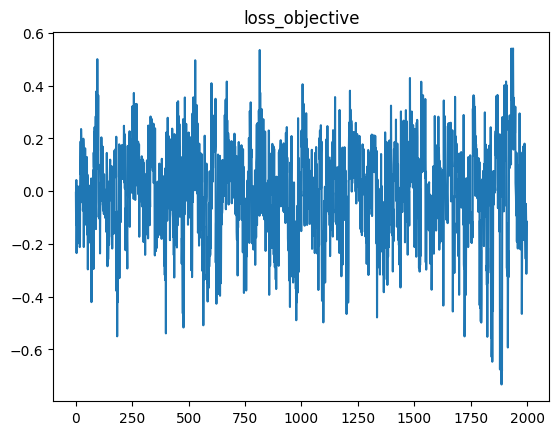

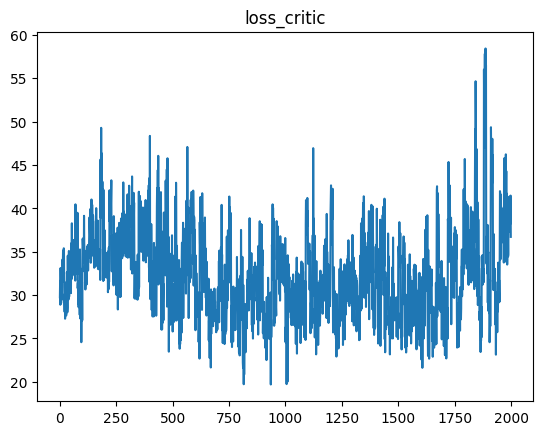

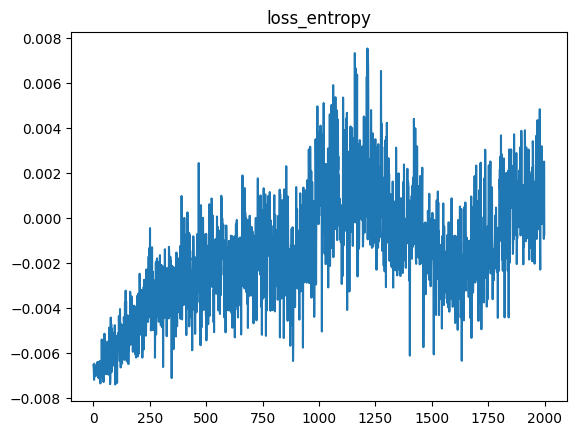

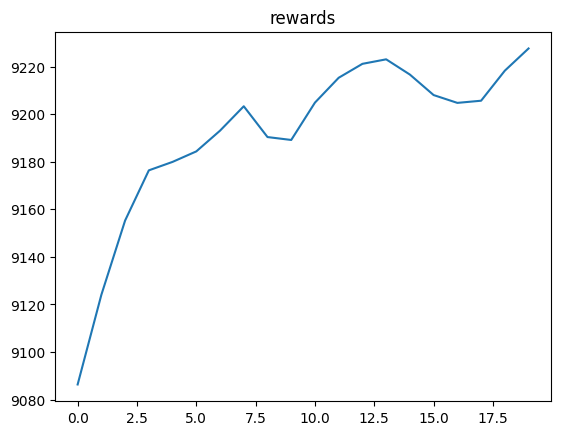

In [ ]:
plt.plot(loss_o)
plt.title("loss_objective")
plt.show()
plt.plot(loss_c)
plt.title("loss_critic")
plt.show()
plt.plot(loss_e)
plt.title("loss_entropy")
plt.show()
plt.plot(rewards)
plt.title("rewards")
plt.show()